# Rail Operations Forecaster
## Notebook 01 — Data Exploration

**Business Objective:**  
Understand the structure, quality, and distributions of the synthetic freight-rail terminal dwell dataset before modeling. This notebook identifies potential data quality issues, explores key variable relationships, and highlights preliminary patterns that will inform feature engineering and baseline model design in later phases.

> **Audience:** This notebook is written to be accessible to analysts who are new to the project while remaining rigorous enough to support later modeling decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting defaults
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## 1. Load the Dataset

We load the Phase 1 synthetic dataset from the project's `data/synthetic/` directory. The dataset records daily operational snapshots across multiple freight-rail terminals.

In [2]:
from pathlib import Path

project_root = Path.cwd().resolve().parent
data_path = project_root / "data" / "synthetic" / "phase1_terminal_dwell.csv"

df = pd.read_csv(data_path, parse_dates=["date"])
print(f"Loaded {len(df):,} rows from: {data_path}")

Loaded 8,760 rows from: /home/jorge/projects/rail-ops-forecaster/data/synthetic/phase1_terminal_dwell.csv


## 2. Shape and Columns

A quick check of the dataset dimensions and the full list of column names.

In [3]:
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumns:")
for col in df.columns:
    print(f"  {col}")

Shape: 8,760 rows × 13 columns

Columns:
  date
  terminal_id
  terminal_name
  region
  inbound_train_count
  inbound_car_count
  cars_on_hand
  yard_occupancy_pct
  crew_starts_available
  locomotive_availability_pct
  is_weekend
  month
  target_dwell_hours


## 3. Row Preview

The first five rows give a concrete sense of what one observation looks like — one terminal on one date.

In [4]:
df.head()

,date,terminal_id,terminal_name,region,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct,is_weekend,month,target_dwell_hours
0,2022-01-01,T01,Barstow,West,13,304,532,59.10,13,92.30,1,1,19.70
1,2022-01-01,T02,Alliance,Midwest,14,388,635,57.70,24,85.70,1,1,17.90
2,2022-01-01,T03,Galesburg,Midwest,12,306,426,56.80,11,87.00,1,1,26.30
3,2022-01-01,T04,Memphis,South,8,175,615,64.70,17,95.70,1,1,26.00
4,2022-01-01,T05,Kansas City,Midwest,13,281,710,59.20,21,82.40,1,1,17.10


## 4. Missing Values

Identifying columns with missing data is a prerequisite before any analysis or modeling. Even a small number of nulls in a key feature can silently distort results.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]

if missing_summary.empty:
    print("No missing values found.")
else:
    display(missing_summary)

No missing values found.


## 5. Data Types

Confirming that each column has the expected dtype — particularly that `date` was parsed as a datetime and that numeric features were not read as strings.

In [6]:
df.dtypes.to_frame(name="dtype")

,dtype
date,datetime64[us]
terminal_id,str
terminal_name,str
region,str
inbound_train_count,int64
inbound_car_count,int64
cars_on_hand,int64
yard_occupancy_pct,float64
crew_starts_available,int64
locomotive_availability_pct,float64


## Date Continuity Check

Lag-based features computed in later notebooks assume one row per terminal per calendar day with no gaps. This check confirms that assumption holds across all terminals before any modeling work begins.

In [ ]:
date_gap_check = (
    df.sort_values(["terminal_id", "date"])
      .groupby("terminal_id")["date"]
      .diff()
      .dt.days
      .dropna()
)

print("Minimum gap in days:", date_gap_check.min())
print("Maximum gap in days:", date_gap_check.max())

# Per-terminal maximum gap
gap_by_terminal = (
    df.sort_values(["terminal_id", "date"])
      .groupby("terminal_id")["date"]
      .apply(lambda x: x.diff().dt.days.dropna().max())
)
print("\nMax daily gap by terminal:")
print(gap_by_terminal)

## 6. Summary Statistics

Descriptive statistics for all numeric columns. Pay attention to the range and spread of `target_dwell_hours` — this is what we will ultimately be predicting.

In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,8760,2023-07-02 00:00:00,2022-01-01 00:00:00,2022-10-01 00:00:00,2023-07-02 00:00:00,2024-04-01 00:00:00,2024-12-30 00:00:00,NaN
inbound_train_count,8760.00,10.49,1.00,7.00,10.00,13.00,30.00,4.39
inbound_car_count,8760.00,239.61,17.00,159.00,230.00,310.00,710.00,107.58
cars_on_hand,8760.00,331.41,40.00,75.00,110.00,539.00,1176.00,395.62
yard_occupancy_pct,8760.00,35.52,10.00,10.00,13.70,75.80,98.00,35.33
crew_starts_available,8760.00,15.70,2.00,11.00,15.00,20.00,40.00,6.27
locomotive_availability_pct,8760.00,88.07,72.10,85.30,88.10,90.90,99.00,4.14
is_weekend,8760.00,0.29,0.00,0.00,0.00,1.00,1.00,0.45
month,8760.00,6.52,1.00,4.00,7.00,10.00,12.00,3.45
target_dwell_hours,8760.00,19.10,6.00,15.90,18.70,21.90,39.90,4.57


## 7. Dwell Summary by Terminal

Aggregating mean and standard deviation of `target_dwell_hours` per terminal reveals whether dwell times vary meaningfully across locations — a strong signal for whether `terminal_id` should be treated as a modeling feature.

In [8]:
dwell_by_terminal = (
    df.groupby(["terminal_id", "terminal_name"])["target_dwell_hours"]
    .agg(mean_dwell="mean", std_dwell="std", n_obs="count")
    .round(2)
    .sort_values("mean_dwell", ascending=False)
    .reset_index()
)
display(dwell_by_terminal)

,terminal_id,terminal_name,mean_dwell,std_dwell,n_obs
0,T04,Memphis,23.17,4.19,1095
1,T03,Galesburg,21.61,4.09,1095
2,T05,Kansas City,20.96,3.60,1095
3,T01,Barstow,20.29,3.75,1095
4,T02,Alliance,18.29,3.25,1095
5,T07,Amarillo,16.86,3.50,1095
6,T06,Stockton,16.17,3.61,1095
7,T08,Havre,15.46,3.87,1095


## 8. Histogram of `target_dwell_hours`

The distribution of the target variable tells us whether it is roughly normal, skewed, or multimodal — all of which have implications for model choice and evaluation metrics.

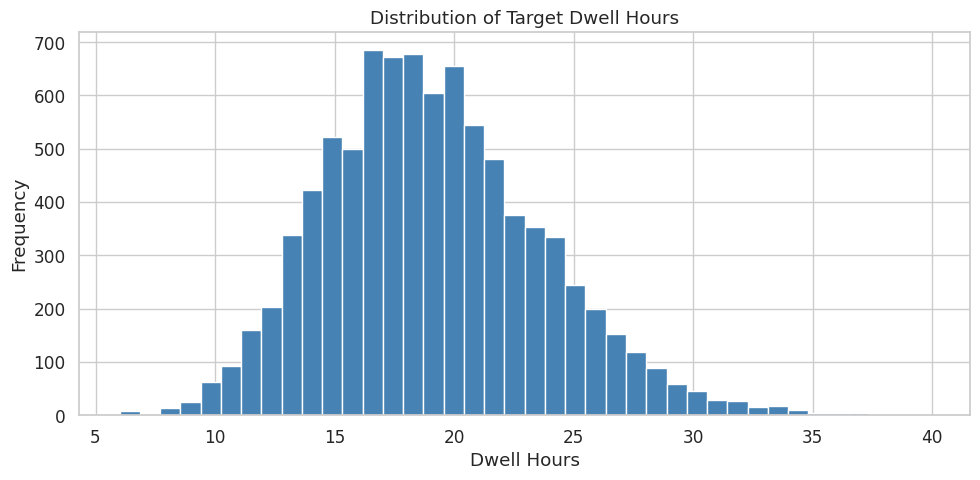

In [9]:
fig, ax = plt.subplots()
ax.hist(df["target_dwell_hours"].dropna(), bins=40, edgecolor="white", color="steelblue")
ax.set_xlabel("Dwell Hours")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Target Dwell Hours")
plt.tight_layout()
plt.show()

## 9. Boxplot of `target_dwell_hours` by Terminal

Boxplots reveal per-terminal medians, spreads, and outliers side by side — making it easy to spot terminals with systematically high or volatile dwell times.

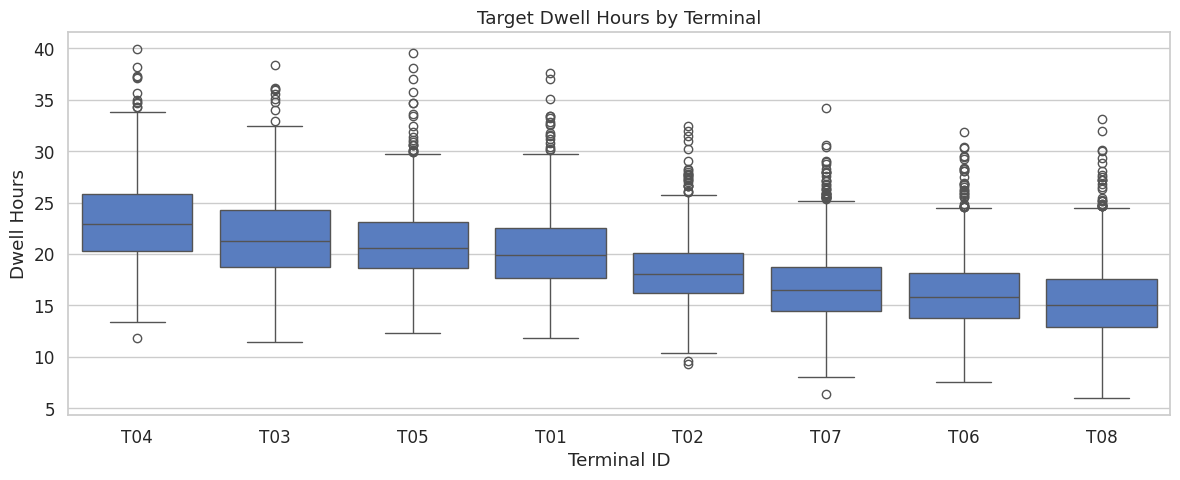

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
order = (
    df.groupby("terminal_id")["target_dwell_hours"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(data=df, x="terminal_id", y="target_dwell_hours", order=order, ax=ax)
ax.set_xlabel("Terminal ID")
ax.set_ylabel("Dwell Hours")
ax.set_title("Target Dwell Hours by Terminal")
plt.tight_layout()
plt.show()

## 10. Scatterplots: Key Features vs `target_dwell_hours`

These scatterplots surface linear or non-linear relationships between individual operational features and the target. Features with a visible trend are strong candidates for inclusion in the baseline model.

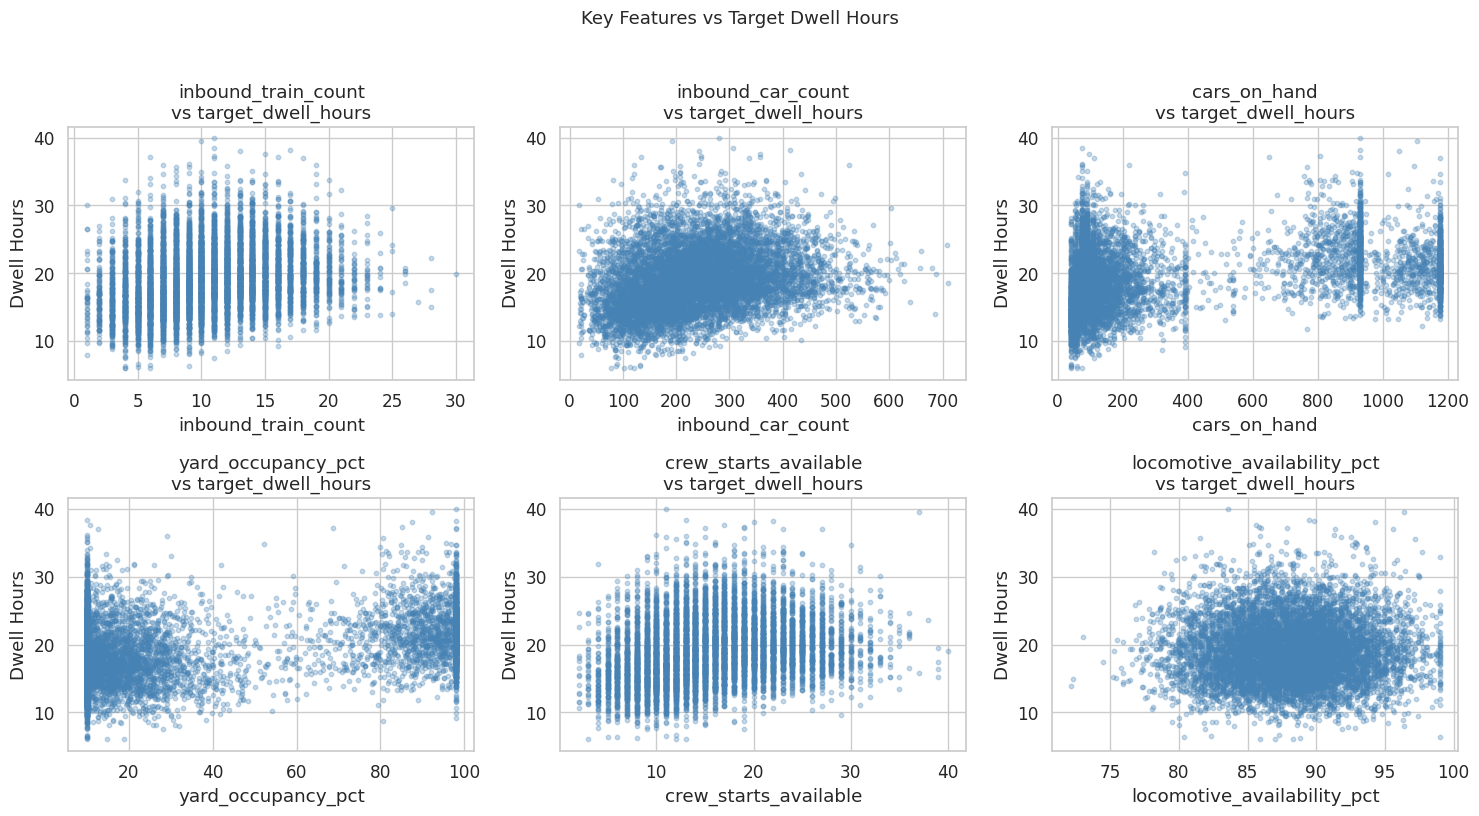

In [11]:
key_features = [
    "inbound_train_count",
    "inbound_car_count",
    "cars_on_hand",
    "yard_occupancy_pct",
    "crew_starts_available",
    "locomotive_availability_pct",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feature in zip(axes, key_features):
    ax.scatter(df[feature], df["target_dwell_hours"], alpha=0.3, s=10, color="steelblue")
    ax.set_xlabel(feature)
    ax.set_ylabel("Dwell Hours")
    ax.set_title(f"{feature}\nvs target_dwell_hours")

plt.suptitle("Key Features vs Target Dwell Hours", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 11. Correlation Heatmap (Numeric Columns Only)

The heatmap shows pairwise Pearson correlations across all numeric features. The column `target_dwell_hours` is the most important row to read — high absolute correlations there indicate features that may have strong predictive power.

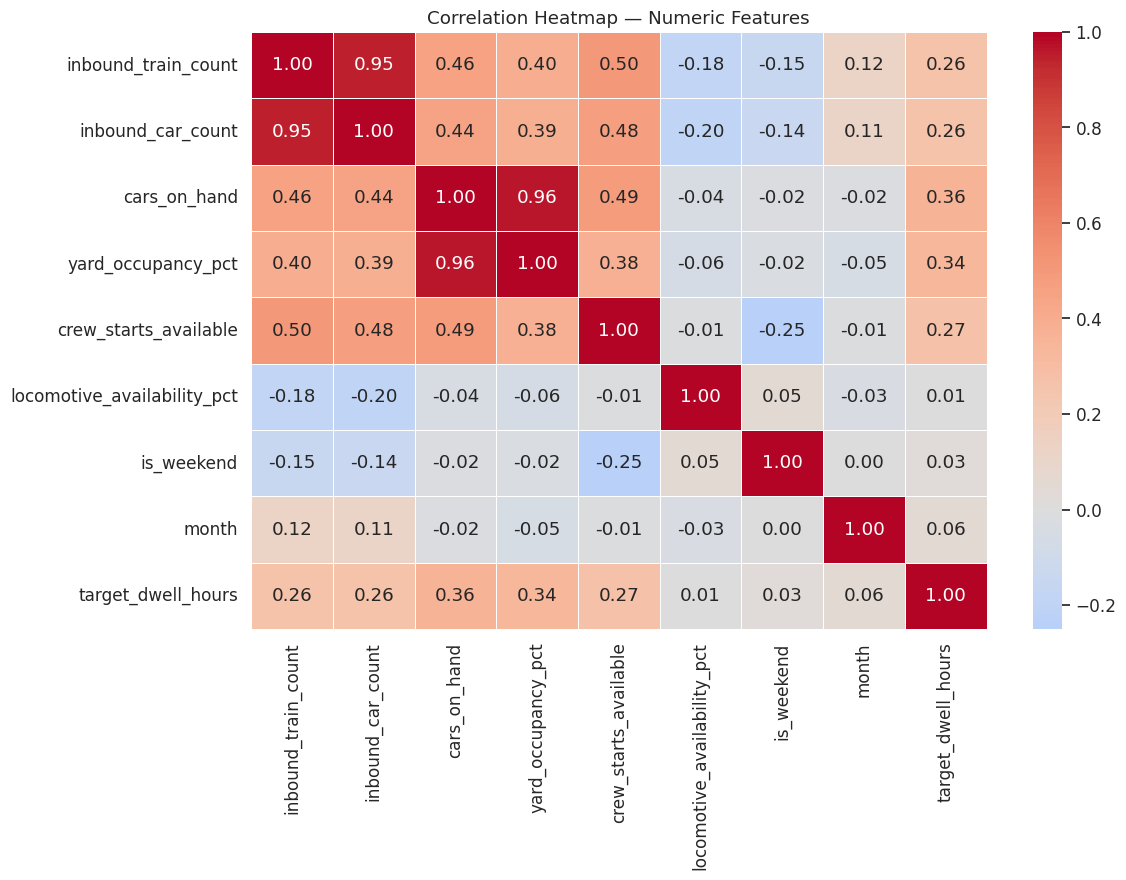

In [12]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

## 12. Preliminary Interpretation

This section summarizes the key findings from the exploration above and outlines next steps.

**Data quality:**
- The dataset contains no missing values and all columns carry the expected dtypes: `date` is a datetime, `terminal_id` and string columns are objects, and all numeric features are int64 or float64. No imputation or casting is required before modeling.

**Target variable (`target_dwell_hours`):**
- The target ranges from 6.0 to 39.9 hours with a mean of 19.1 h and a standard deviation of 4.6 h. The mean exceeds the median slightly, indicating a moderate right skew driven by occasional high-dwell events in the upper tail. Log transformation is unlikely to be necessary for tree-based models, but may be worth revisiting if residual patterns at high dwell levels are systematic.

**Terminal-level variation:**
- Terminal mean dwell ranges from 15.5 h (T08 Havre) to 23.2 h (T04 Memphis) — a spread of nearly 8 hours. This variation is large enough to make `terminal_id` a necessary modeling feature. The standard deviation within each terminal (roughly 3–4 h) is also consistent enough to suggest stable, learnable patterns at the yard level.

**Feature relationships:**
- The scatterplots indicate that `cars_on_hand` and `yard_occupancy_pct` have the most visible relationships with dwell hours among the operational features. `inbound_car_count` shows a positive trend, while `locomotive_availability_pct` and `crew_starts_available` show weaker or noisier signals. The correlation heatmap confirms these impressions and does not indicate severe multicollinearity among the candidate features.

**Next steps:**
- Proceed to `02_baseline_model.ipynb` for feature selection, time-based train/test splitting, and initial model fitting.
- Consider whether `is_weekend` and `month` should remain as simple calendar features or whether later phases may benefit from richer seasonal handling.